# Performance Notebook 3

# Lecture 8: Computer Arithmetic & Numerical Accuracy

## M1: Mandelbrot Trajectory Divergence

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def escape_and_divergence_maps(N: int,MAX_ITER: int,TAU: float):
    x = np.linspace(-0.7530, -0.7490, N)
    y = np.linspace(0.0990, 0.1030, N)

    C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
    C32 = C64.astype(np.complex64)

    z32 = np.zeros_like(C32)
    z64 = np.zeros_like(C64)

    # Divergence tracking
    diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
    active = np.ones((N, N), dtype=bool)

    # Escape tracking
    escape_iter = np.full((N, N), MAX_ITER, dtype=np.int32)
    escaped = np.zeros((N, N), dtype=bool)

    for k in range(MAX_ITER):
        if not active.any():
            break

        # iterate both precisions
        z32[active] = z32[active]**2 + C32[active]
        z64[active] = z64[active]**2 + C64[active]

        # divergence
        diff = (
            np.abs(z32.real.astype(np.float64) - z64.real)
            + np.abs(z32.imag.astype(np.float64) - z64.imag)
        )

        newly_div = active & (diff > TAU)
        diverge[newly_div] = k
        active[newly_div] = False

        # escape count 
        mag = np.abs(z64)
        newly_esc = (~escaped) & (mag > 2)

        escape_iter[newly_esc] = k
        escaped[newly_esc] = True

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Divergence map
    im1 = ax[0].imshow(
        diverge,
        cmap='plasma',
        origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030]
    )
    ax[0].set_title(f'Divergence (tau={TAU})')
    fig.colorbar(im1, ax=ax[0],label=
    'First divergence iteration')

    # Escape map
    im2 = ax[1].imshow(
        escape_iter,
        cmap='viridis',
        origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030]
    )
    ax[1].set_title('Escape count')
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()
    print(f" The Max iteration for any pixel to diverge for {TAU=} is {np.max(diverge)}")
    amount_diverged = np.sum(diverge < MAX_ITER)
    fraction_diverged = amount_diverged / ( N * N)
    print(f"Fraction diverged for {TAU=}:", fraction_diverged)
    amount_diverged_500 = np.sum(diverge < 500)
    fraction_diverged_500 = 1 -( amount_diverged_500 / ( N * N))
    print(f"Fraction diverged above 500 iterations {TAU=}:", fraction_diverged_500)

    idx = np.nanargmax(diverge)
    i, j = np.unravel_index(idx, diverge.shape)
    print(f"X,Y Coordinate for highest iteration for divergence: {C64[i, j]} With iters of {diverge[i, j]}")

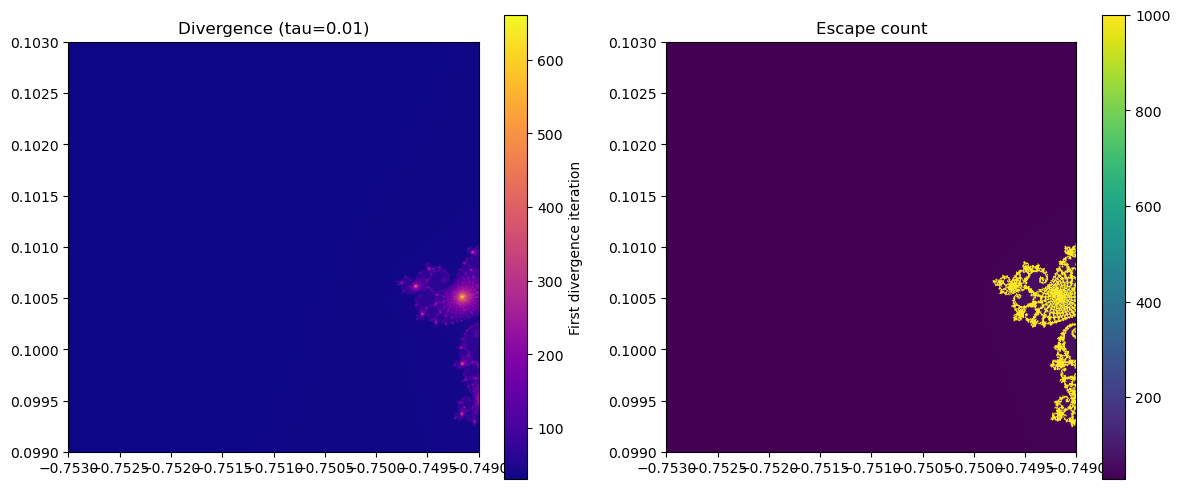

 The Max iteration for any pixel to diverge for TAU=0.01 is 661
Fraction diverged for TAU=0.01: 1.0
Fraction diverged above 500 iterations TAU=0.01: 3.814697265625e-05
X,Y Coordinate for highest iteration for divergence: (-0.7491565557729941+0.10051076320939335j) With iters of 661


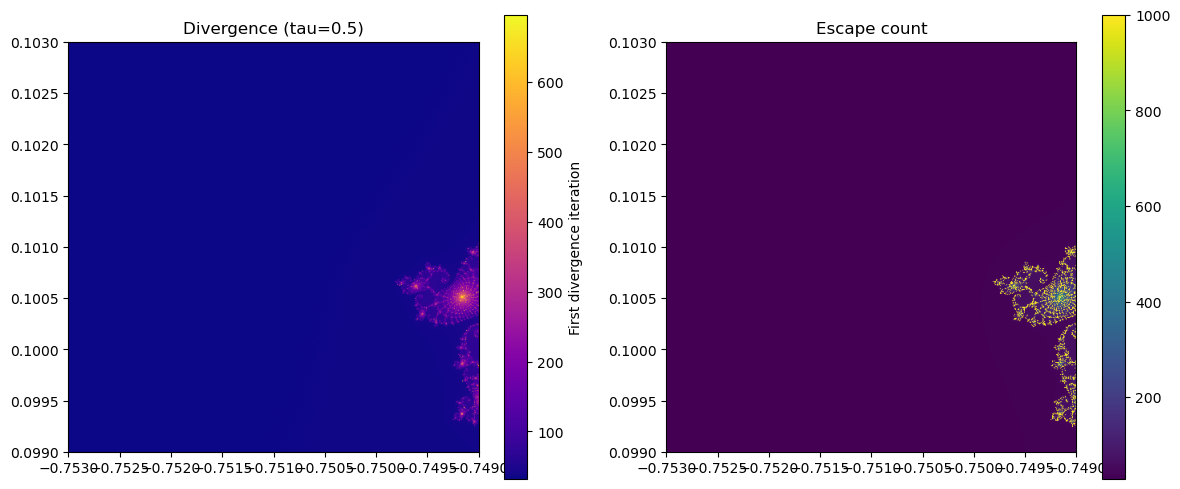

 The Max iteration for any pixel to diverge for TAU=0.5 is 696
Fraction diverged for TAU=0.5: 1.0
Fraction diverged above 500 iterations TAU=0.5: 0.000141143798828125
X,Y Coordinate for highest iteration for divergence: (-0.7491565557729941+0.10051076320939335j) With iters of 696


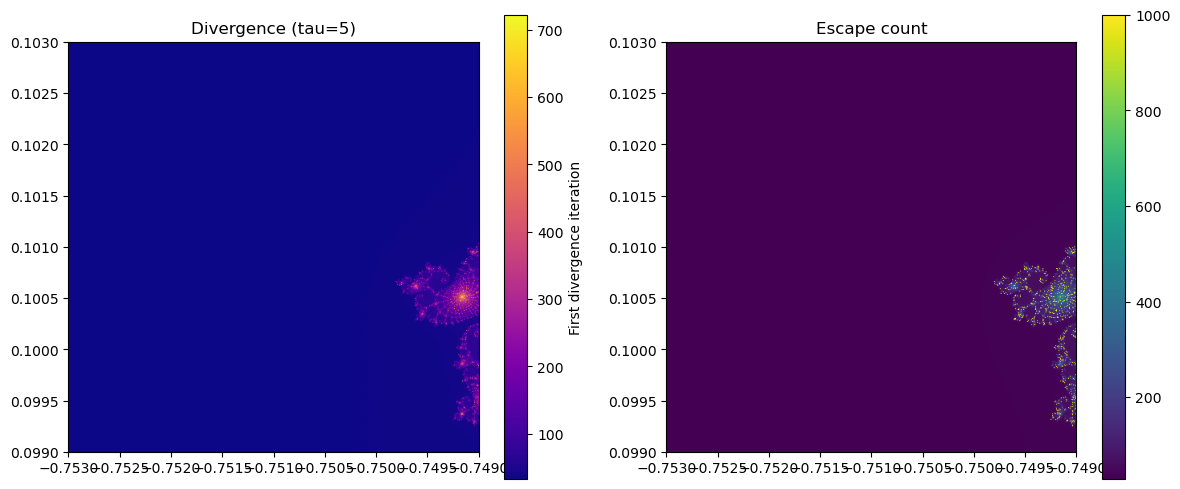

 The Max iteration for any pixel to diverge for TAU=5 is 722
Fraction diverged for TAU=5: 1.0
Fraction diverged above 500 iterations TAU=5: 0.000186920166015625
X,Y Coordinate for highest iteration for divergence: (-0.749133072407045+0.10051859099804306j) With iters of 722


In [57]:
N, MAX_ITER = 512, 1000
TAUS=[0.01,0.5,5]
for TAU in TAUS:
    escape_and_divergence_maps(N,MAX_ITER,TAU)

### What fraction of pixels diverge before max iter?
MAX_ITER is set to 1000, it can be observed that the Fraction diverged = 1 for the three TAUS i have set, meaning that all pixels result in a difference between float32 and float64 exceeding TAU, before 1000 iterations

To set another measure 500 is also used to see. Fraction diverged above 500 iterations, and seing how this responds depending on TAU.

Where it can be observed what is expected as we set TAU higher more pixel need more iterations for diverging

### Where do trajectories diverge early? Compare visually to the escape-count map.
It can be observed that alot of them deverge earlier specifcally not the region of x = [-0.7500,-0.7490] y=[0.1015,0.0995], which can also be related over to the escape map where we generally see these points also having escaped eariler.

If we instead do look at the region of x = [-0.7500,-0.7490] y=[0.1015,0.0995]. We can observe that earlier devirgence result in higher escape count. 
Seen as when we change tau to an higher value the Fraction diverged above 500 iterations becomes higher and looking at the escape map it can be observe we get less yellow pixels (1000 iteration for escaping)

### Does early divergence correlate with high escape iteration counts?
Based on the region of x = [-0.7500,-0.7490] y=[0.1015,0.0995] yes we can clearly see this correlation between the two visually.

## M2: Mandelbrot Sensitivity Map

X,Y Coordinate for Max Kappa: (-0.7491956947162427+0.09999412915851272j) With value of 56279933.67272727


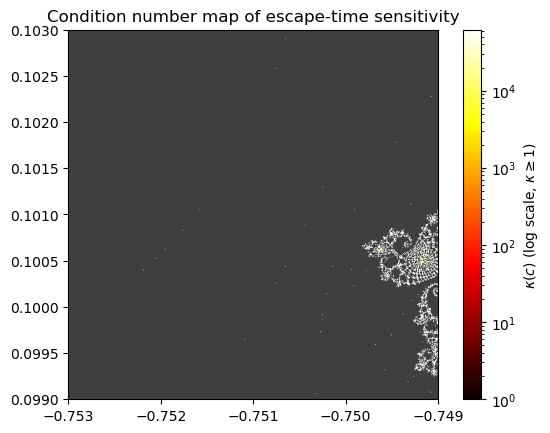

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER = 512, 1000

x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace(0.0990, 0.1030, N)

C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)

eps32 = np.finfo(np.float32).eps
delta = np.maximum(eps32 * np.abs(C), 1e-10)


def escape_count(C, max_iter):
    z = np.zeros_like(C)
    cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]

        newly = (~esc) & (np.abs(z) > 2.0)
        cnt[newly] = k
        esc[newly] = True

    return cnt


n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)

dn = np.abs(n_base - n_perturb)

kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)

# to find the indx of kappa max
idx = np.nanargmax(kappa)
i, j = np.unravel_index(idx, kappa.shape)
print(f"X,Y Coordinate for Max Kappa: {C[i, j]} With value of {kappa[i, j]}")

cmap_k = plt.cm.hot.copy()
cmap_k.set_bad('0.25')

vmax = np.nanpercentile(kappa, 99)

plt.imshow(
    kappa,
    cmap=cmap_k,
    origin='lower',
    extent=[-0.7530, -0.7490, 0.0990, 0.1030],
    norm=LogNorm(vmin=1, vmax=vmax)
)

plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title('Condition number map of escape-time sensitivity')
plt.show()


### Where is κ largest? Does it match the boundary in M1?
We can clearly regonize the same pattern of pixels form M1. 

Specifcally the point may not match but the pattern definately does.

If we compare to tau = 0.01 and find its point with most need iteration to diverge we have:

X,Y Coordinate for highest iteration for divergence: (-0.7491565557729941+0.10051076320939335j) With iters of 661

where we here in the sentivity map have it to be 

X,Y Coordinate for Max Kappa: (-0.7491956947162427+0.09999412915851272j) With value of 56279933.67272727

We can generally see the boundary from M1



### what is k for interior pixels (n = max_iter)?
we can generally see that that this are very low value from the dark pixels and more accurately if print kappa array, we can observe taht we get alot of 0s.

from which we can say that the pixels have close or equal to k = 0.

In [ ]:
print("Points for kappa")
print(kappa)


Points for kappa
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


which also make sense based of the formula